## Imports and function definitions

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
# Graph aesthetics settings
import matplotlib.pyplot as plt
from cycler import cycler
import seaborn as sns
large = 20; medium = 16; small = 12
colors = ['#66bb6a', '#558ed5', '#dd6a63', '#dcd0ff', '#ffa726', '#8c5eff', '#f44336', '#00bcd4', '#ffc107', '#9c27b0']
text_color = "#404040"

params = {'axes.titlesize': medium,
          'legend.fontsize': small,
          'figure.figsize': (16, 16),
          'axes.labelsize': small,
          'axes.linewidth': 2,
          'xtick.labelsize': small,
          'xtick.color': text_color,
          'ytick.color': text_color,
          'ytick.labelsize': small,
          'axes.edgecolor': text_color,
          'figure.titlesize': small,
          'axes.prop_cycle': cycler(color=colors),
          'axes.titlecolor': text_color,
          'axes.labelcolor': text_color,
         }

plt.rcParams.update(params)

In [3]:
def plot_loss(solver):
    history = solver.metrics_history
    plt.figure(figsize=(8,5))
    plt.plot(np.log10(history['train_loss']), label = 'Train')
    
    # Add axis labels, title and legend for clarity
    plt.title('Loss plot')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_results(solver):
    history = solver.metrics_history
    t_vals = solver._generate_batch('train')
    u_pred = solver.get_solution()(t_vals, to_numpy=True)
    plt.figure(figsize=(8,5))
    #plt.plot(t_vals, [np.sin(i) for i in t_vals], c = colors[1])
    plt.plot(t_vals[0].reshape(-1, 1).cpu().detach().numpy(), u_pred.reshape(-1, 1), c = colors[1])
    
    # Add axis labels and title for clarity
    plt.title(f'Neural Network approximation at {len(history["train_loss"])} epochs.')
    plt.xlabel('u')
    plt.ylabel('t')
    plt.grid(True)
    plt.show()
    return t_vals[0].reshape(1, -1).cpu().detach().numpy(), u_pred

In [4]:
import torch
import numpy as np
from neurodiffeq import diff      
from neurodiffeq.ode import solve 
from neurodiffeq.conditions import IVP 
from neurodiffeq.networks import FCNN
from neurodiffeq.solvers import Solver1D
from neurodiffeq.generators import Generator1D

C:\Users\laksh\anaconda3\envs\torch\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [5]:
import sys
import inspect
import torch.nn as nn
from copy import deepcopy
from tqdm.auto import tqdm
from abc import ABC, abstractmethod
from neurodiffeq.generators import SamplerGenerator
from neurodiffeq.solvers_utils import PretrainedSolver
from neurodiffeq._version_utils import deprecated_alias

## IVP

In [6]:
class BaseCondition:
    def __init__(self):
        self.ith_unit = None

    def parameterize(self, output_tensor, *input_tensors):
        raise ValueError(f"Abstract {self.__class__.__name__} cannot be parameterized")  # pragma: no cover

    def enforce(self, net, *coordinates):
        # concatenate the coordinates and pass to network
        coordinates = coordinates[0]
        network_output = net(coordinates)
        # parameterize the raw output and return
        return self.parameterize(network_output, *coordinates)



class IVP(BaseCondition):
    @deprecated_alias(x_0='u_0', x_0_prime='u_0_prime')
    def __init__(self, t_0, u_0=None, u_0_prime=None):
        super().__init__()
        self.t_0, self.u_0, self.u_0_prime = t_0, u_0, u_0_prime

    def parameterize(self, output_tensor, t):
        output_tensor = output_tensor.reshape(-1)
        if self.u_0_prime is None:
            return self.u_0 + (1 - torch.exp(-t + self.t_0)) * output_tensor
        else:
            return self.u_0 + (t - self.t_0) * self.u_0_prime + ((1 - torch.exp(-t + self.t_0)) ** 2) * output_tensor

## BaseSolver

In [7]:
def _requires_closure(optimizer):
    # starting from torch v1.13, simple optimizers no longer have a `closure` argument
    closure_param = inspect.signature(optimizer.step).parameters.get('closure')
    return closure_param and closure_param.default == inspect._empty

class BaseSolver(ABC, PretrainedSolver):
    @deprecated_alias(criterion='loss_fn')
    def __init__(self, diff_eqs, conditions,
                 nets=None, train_generator=None, valid_generator=None, analytic_solutions=None,
                 optimizer=None, loss_fn=None, n_batches_train=1, n_batches_valid=4,
                 metrics=None, n_input_units=None, n_output_units=None,
                 # deprecated arguments are listed below
                 shuffle=None, batch_size=None):
        # deprecate argument `shuffle`
        if shuffle:
            warnings.warn(
                "param `shuffle` is deprecated and ignored; shuffling should be performed by generators",
                FutureWarning,
            )
        # deprecate argument `batch_size`
        if batch_size is not None:
            warnings.warn(
                "param `batch_size` is deprecated and ignored; specify n_batches_train and n_batches_valid instead",
                FutureWarning,
            )

        self.diff_eqs = diff_eqs
        self.conditions = conditions
        self.n_funcs = len(conditions)
        if nets is None:
            self.nets = [
                FCNN(n_input_units=n_input_units, n_output_units=n_output_units, hidden_units=(32, 32), actv=nn.Tanh)
                for _ in range(self.n_funcs)
            ]
        else:
            self.nets = nets

        if train_generator is None:
            raise ValueError("train_generator must be specified")

        if valid_generator is None:
            raise ValueError("valid_generator must be specified")

        self.metrics_fn = metrics if metrics else {}
        # For backward compatibility with the legacy `analytic_solutions` argument
        if analytic_solutions:
            warnings.warn(
                'The `analytic_solutions` argument is deprecated and could lead to unstable behavior. '
                'Pass a `metrics` dict instead.',
                FutureWarning,
            )

            def analytic_mse(*args):
                x = args[-n_input_units:]
                u_hat = analytic_solutions(*x)
                u = args[:-n_input_units]
                u, u_hat = torch.stack(u), torch.stack(u_hat)
                return ((u - u_hat) ** 2).mean()

            if 'analytic_mse' in self.metrics_fn:
                warnings.warn(
                    "Ignoring `analytic_solutions` in presence of key 'analytic_mse' in `metrics`",
                    FutureWarning,
                )
            else:
                self.metrics_fn['analytic_mse'] = analytic_mse

        # metric history, keys will be train_loss, valid_loss, train__<metric_name>, valid__<metric_name>.
        # For compatibility with ode.py and pde.py,
        # double underscore are used between 'train'/'valid' and custom metric names.
        self.metrics_history = {}
        self.metrics_history.update({'train_loss': [], 'valid_loss': []})
        self.metrics_history.update({'train__' + name: [] for name in self.metrics_fn})
        self.metrics_history.update({'valid__' + name: [] for name in self.metrics_fn})

        self.optimizer = optimizer if optimizer else Adam(OrderedSet(chain.from_iterable(n.parameters() for n in self.nets)))
        self._set_loss_fn(loss_fn)

        def make_pair_dict(train=None, valid=None):
            return {'train': train, 'valid': valid}

        self.generator = make_pair_dict(
            train=SamplerGenerator(train_generator),
            valid=SamplerGenerator(valid_generator),
        )
        # number of batches for training / validation;
        self.n_batches = make_pair_dict(train=n_batches_train, valid=n_batches_valid)
        # current batch of samples, kept for additional_loss term to use
        self._batch = make_pair_dict()
        if self.n_batches['valid'] == 0 and _requires_closure(self.optimizer):
            warnings.warn(f"Setting n_batches_valid=0 will update lowest_loss and best_net with training loss "
                          f"instead of validation loss. "
                          f"This is a problem for {self.optimizer.__class__} optimizer "
                          f"because it updates the parameters before the training loss computed. "
                          f"This leads to potentially worse solution in `best_net`!", RuntimeWarning)
        # current network with lowest loss
        self.best_nets = None
        # current lowest loss
        self.lowest_loss = None
        # local epoch in a `.fit` call, should only be modified inside self.fit()
        self.local_epoch = 0
        # maximum local epochs to run in a `.fit()` call, should only set by inside self.fit()
        self._max_local_epoch = 0
        # controls early stopping, should be set to False at the beginning of a `.fit()` call
        # and optionally set to False by `callbacks` in `.fit()` to support early stopping
        self._stop_training = False
        # the _phase variable is registered for callback functions to access
        self._phase = None

    def _set_loss_fn(self, criterion):
        if criterion is None:
            self.loss_fn = lambda r, f, x: (r ** 2).mean()
        elif isinstance(criterion, nn.modules.loss._Loss):
            self.loss_fn = lambda r, f, x: criterion(r, torch.zeros_like(r))
        elif isinstance(criterion, str):
            self.loss_fn = _losses[criterion.lower()]
        elif callable(criterion):
            self.loss_fn = criterion
        else:
            raise TypeError(f"Unknown type of criterion {type(criterion)}")

    @property
    def global_epoch(self):
        return len(self.metrics_history['train_loss'])

    @property
    def batch(self):
        return self._batch

    @property
    def _batch_examples(self):
        warnings.warn(
            '`._batch_examples` has been deprecated in favor of `._batch` and will be removed in a future version',
            FutureWarning,
        )
        return self._batch

    @property
    def criterion(self):
        warnings.warn(
            f'`{self.__class__.__name__}`.criterion is a deprecated alias for `{self.__class__.__name__}.loss_fn`.'
            f'The alias is only meant to be accessed by certain functions in `neurodiffeq.solver_utils` '
            f'until proper fixes are made; by which time this alias will be removed.'
        )
        return self.loss_fn

    @criterion.setter
    def criterion(self, loss_fn):
        warnings.warn(
            f'`{self.__class__.__name__}`.criterion is a deprecated alias for `{self.__class__.__name__}.loss_fn`.'
            f'The alias is only meant to be accessed by certain functions in `neurodiffeq.solver_utils` '
            f'until proper fixes are made; by which time this alias will be removed.'
        )
        self.loss_fn = loss_fn

    def compute_func_val(self, net, cond, *coordinates):
        return cond.enforce(net, *coordinates)

    def _update_history(self, value, metric_type, key):
        self._phase = key
        if metric_type == 'loss':
            self.metrics_history[f'{key}_{metric_type}'].append(value)
        elif metric_type in self.metrics_fn:
            self.metrics_history[f'{key}__{metric_type}'].append(value)
        else:
            raise KeyError(f"metric '{metric_type}' not specified")

    def _update_train_history(self, value, metric_type):
        self._update_history(value, metric_type, key='train')

    def _update_valid_history(self, value, metric_type):
        self._update_history(value, metric_type, key='valid')

    def _generate_batch(self, key):
        # the following side effects are helpful for future extension,
        # especially for additional loss term that depends on the coordinates
        self._phase = key
        self._batch[key] = [v.reshape(-1, 1) for v in self.generator[key].get_examples()]
        return self._batch[key]

    def _generate_train_batch(self):
        return self._generate_batch('train')

    def _generate_valid_batch(self):
        return self._generate_batch('valid')

    def _do_optimizer_step(self, closure=None):
        self.optimizer.step(closure=closure)

    def _run_epoch(self, key):
        if self.n_batches[key] <= 0:
            # XXX maybe we should append NaN to metric history?
            return
        self._phase = key
        epoch_loss = 0.0
        batch_loss = 0.0
        metric_values = {name: 0.0 for name in self.metrics_fn}

        # Zero the gradient only once, before running the batches. Gradients of different batches are accumulated.
        if key == 'train' and not _requires_closure(self.optimizer):
            self.optimizer.zero_grad()

        # perform forward pass for all batches: a single graph is created and release in every iteration
        # see https://discuss.pytorch.org/t/why-do-we-need-to-set-the-gradients-manually-to-zero-in-pytorch/4903/17
        for batch_id in range(self.n_batches[key]):
            batch = self._generate_batch(key)
            batch = [batch[0].view(1, -1)] ## added

            def closure(zero_grad=True):
                nonlocal batch_loss
                if key == 'train' and zero_grad:
                    self.optimizer.zero_grad()
                funcs = [
                    self.compute_func_val(n, c, *batch) for n, c in zip(self.nets, self.conditions)
                ]

                for name in self.metrics_fn:
                    value = self.metrics_fn[name](*funcs, *batch).item()
                    metric_values[name] += value
                residuals = self.diff_eqs(*funcs, *batch)
                residuals = torch.cat(residuals, dim=1)
                try:
                    loss = self.loss_fn(residuals, funcs, batch) + self.additional_loss(residuals, funcs, batch)
                except TypeError as e:
                    warnings.warn(
                        "You might need to update your code. "
                        "Since v0.4.0; both `criterion` and `additional_loss` requires three inputs: "
                        "`residual`, `funcs`, and `coords`. See documentation for more.", FutureWarning)
                    raise e

                # accumulate gradients before the current graph is collected as garbage
                if key == 'train':
                    loss.backward()
                    batch_loss = loss.item()
                return loss
            # batch = batch.view(1, -1) ## added
            if key == 'train':
                if _requires_closure(self.optimizer):
                    # If `closure` is required by `optimizer.step()`, perform a step for every batch
                    self._do_optimizer_step(closure=closure)
                else:
                    # Otherwise, only perform backward propagation.
                    # Optimizer step will be performed only once outside the for-loop (i.e. after all batches).
                    closure(zero_grad=False)
                epoch_loss += batch_loss
            else:
                epoch_loss += closure().item()

        # calculate mean loss of all batches and register to history
        self._update_history(epoch_loss / self.n_batches[key], 'loss', key)

        # If validation is performed, update the best network with the validation loss
        # Otherwise, try to update the best network with the training loss
        if key == 'valid' or self.n_batches['valid'] == 0:
            self._update_best(key)

        # perform the optimizer step after all batches are run (if optimizer.step doesn't require `closure`)
        if key == 'train' and not _requires_closure(self.optimizer):
            self._do_optimizer_step()

        # calculate average metrics across batches and register to history
        for name in self.metrics_fn:
            self._update_history(
                metric_values[name] / self.n_batches[key], name, key)

    def run_train_epoch(self):
        self._run_epoch('train')

    def run_valid_epoch(self):
        self._run_epoch('valid')

    def _update_best(self, key):
        current_loss = self.metrics_history[key + '_loss'][-1]
        if (self.lowest_loss is None) or current_loss < self.lowest_loss:
            self.lowest_loss = current_loss
            self.best_nets = deepcopy(self.nets)

    def fit(self, max_epochs, callbacks=(), tqdm_file=sys.stderr, **kwargs):
        self._stop_training = False
        self._max_local_epoch = max_epochs

        monitor = kwargs.pop('monitor', None)
        if monitor:
            warnings.warn("Passing `monitor` is deprecated, "
                          "use a MonitorCallback and pass a list of callbacks instead")
            callbacks = [monitor.to_callback()] + list(callbacks)
        if kwargs:
            raise ValueError(f'Unknown keyword argument(s): {list(kwargs.keys())}')  # pragma: no cover

        if tqdm_file is None:
            loop = range(max_epochs)
        else:
            loop = tqdm(
                range(max_epochs),
                desc='Training Progress',
                colour='blue',
                file=tqdm_file,
                dynamic_ncols=True,
            )

        for local_epoch in loop:
            # stop training if self._stop_training is set to True by a callback
            if self._stop_training:
                break

            # register local epoch (starting from 1 instead of 0) so it can be accessed by callbacks
            self.local_epoch = local_epoch + 1
            self.run_train_epoch()
            self.run_valid_epoch()

            for cb in callbacks:
                cb(self)

    @abstractmethod
    def get_solution(self, copy=True, best=True):
        pass  # pragma: no cover

    def _get_internal_variables(self):

        return {
            "metrics": self.metrics_fn,
            "n_batches": self.n_batches,
            "best_nets": self.best_nets,
            "criterion": self.loss_fn,
            "loss_fn": self.loss_fn,
            "conditions": self.conditions,
            "global_epoch": self.global_epoch,
            "lowest_loss": self.lowest_loss,
            "n_funcs": self.n_funcs,
            "nets": self.nets,
            "optimizer": self.optimizer,
            "diff_eqs": self.diff_eqs,
            "generator": self.generator,
            "train_generator": self.generator['train'],
            "valid_generator": self.generator['valid'],
        }

    @deprecated_alias(param_names='var_names')
    def get_internals(self, var_names=None, return_type='list'):
        available_variables = self._get_internal_variables()

        if var_names == "all" or var_names is None:
            return available_variables

        if isinstance(var_names, str):
            return available_variables[var_names]

        if return_type == 'list':
            return [available_variables[name] for name in var_names]
        elif return_type == "dict":
            return {name: available_variables[name] for name in var_names}
        else:
            raise ValueError(f"unrecognized return_type = {return_type}")

    def additional_loss(self, residual, funcs, coords):
        return 0.0

    def get_residuals(self, *coords, to_numpy=False, best=True, no_reshape=False):
        coords = [c if isinstance(c, torch.Tensor) else torch.tensor(c) for c in coords]
        original_shape = coords[0].shape
        coords = [c.reshape(-1, 1).requires_grad_() for c in coords]
        solution = self.get_solution(copy=False, best=best)
        funcs = solution(*coords, to_numpy=False, no_reshape=no_reshape)
        if isinstance(funcs, torch.Tensor):
            funcs = [funcs]
        residuals = self.diff_eqs(*funcs, *coords)
        if not no_reshape:
            residuals = [r.reshape(*original_shape) for r in residuals]
        if to_numpy:
            residuals = [r.detach().cpu().numpy() for r in residuals]
        return residuals if len(residuals) > 1 else residuals[0]

## BaseSolution

In [8]:
class BaseSolution(ABC):
    def __init__(self, nets, conditions):
        if nets is None:
            raise RuntimeError("The nets cannot be None, check if you disabled validation "
                               "and used `best`=True with `get_solution` / `get_residual`")
        if isinstance(nets, nn.Module):
            # This is for backward compatibility with the `single_net` option
            # The same torch.nn.Module instance is repeated to form a list of the same length as `conditions`
            self.nets = [nets] * len(conditions)
        else:
            self.nets = nets
        self.conditions = conditions

    @abstractmethod
    def _compute_u(self, net, condition, *coords):
        pass  # pragma: no cover

    @deprecated_alias(as_type='to_numpy')
    def __call__(self, *coords, to_numpy=False, no_reshape=True):
        coords = [coords[0][0].view(1,-1)]
        # coords = [c if isinstance(c, torch.Tensor) else torch.tensor(c) for c in coords]
        # original_shape = coords[0].shape
        # coords = [c.reshape(-1, 1) for c in coords]
        # if isinstance(to_numpy, str):
        #     # Why did we allow `tf` as an option >_<
        #     # We should phase this out as soon as possible
        #     if to_numpy == 'tf' or to_numpy == 'torch':
        #         to_numpy = False
        #     elif to_numpy == 'np':
        #         to_numpy = True
        #     else:
        #         raise ValueError(f"Unrecognized `as_type` option: '{to_numpy}'")

        us = [
            self._compute_u(net, con, *coords)
            for con, net in zip(self.conditions, self.nets)
        ]
        if not no_reshape:
            us = [u.reshape(*original_shape) for u in us]
        if to_numpy:
            us = [u.detach().cpu().numpy() for u in us]

        return us if len(self.nets) > 1 else us[0]

## Solver1D

In [9]:
class Solver1D(BaseSolver):
    def __init__(self, ode_system, conditions, t_min=None, t_max=None,
                 nets=None, train_generator=None, valid_generator=None, analytic_solutions=None, optimizer=None,
                 loss_fn=None, n_batches_train=1, n_batches_valid=4, metrics=None, n_output_units=1,
                 # deprecated arguments are listed below
                 batch_size=None, shuffle=None):

        if train_generator is None or valid_generator is None:
            if t_min is None or t_max is None:
                raise ValueError(f"Either generator is not provided, t_min and t_max should be both provided: \n"
                                 f"got t_min={t_min}, t_max={t_max}, "
                                 f"train_generator={train_generator}, valid_generator={valid_generator}")

        if train_generator is None:
            train_generator = Generator1D(32, t_min=t_min, t_max=t_max, method='equally-spaced-noisy')
        if valid_generator is None:
            valid_generator = Generator1D(32, t_min=t_min, t_max=t_max, method='equally-spaced')

        self.t_min, self.t_max = t_min, t_max

        super(Solver1D, self).__init__(
            diff_eqs=ode_system,
            conditions=conditions,
            nets=nets,
            train_generator=train_generator,
            valid_generator=valid_generator,
            analytic_solutions=analytic_solutions,
            optimizer=optimizer,
            loss_fn=loss_fn,
            n_batches_train=n_batches_train,
            n_batches_valid=n_batches_valid,
            metrics=metrics,
            n_input_units=1,
            n_output_units=n_output_units,
            shuffle=shuffle,
            batch_size=batch_size,
        )

    def get_solution(self, copy=True, best=True):
        nets = self.best_nets if best else self.nets
        conditions = self.conditions
        if copy:
            nets = deepcopy(nets)
            conditions = deepcopy(conditions)

        return Solution1D(nets, conditions)

    def _get_internal_variables(self):
        available_variables = super(Solver1D, self)._get_internal_variables()
        available_variables.update({
            't_min': self.t_min,
            't_max': self.t_max,
        })
        return available_variables

class Solution1D(BaseSolution):
    def _compute_u(self, net, condition, ts):
        return condition.enforce(net, ts)

## Run

Training Progress:   0%|                                                                      | 0/1000 [00:00<…

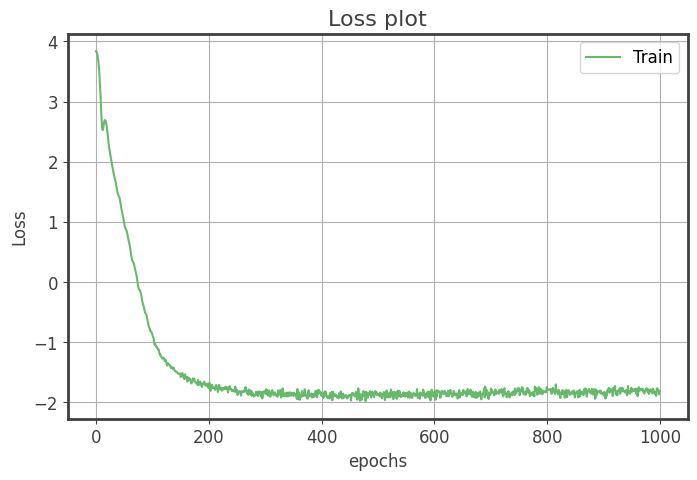

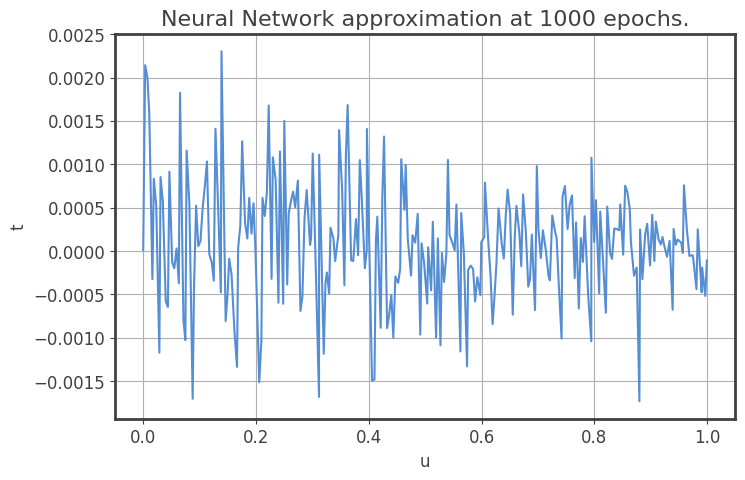

In [11]:
def harmonic_oscillator(u, t):
    u, t = u.view(-1, 1), t.view(-1, 1)
    return [diff(u, t, order=2) + 16*torch.pi**2*torch.sin(u)]
init_val_ho = [IVP(t_0=0.0, u_0=0.0, u_0_prime=1.0)]
nets = [FCNN(n_input_units=256, n_output_units=256, hidden_units=[32, 32, 32])]#, 32, 32])]
t_min = 0
t_max = 1
train_g = Generator1D(256, t_min, t_max , method='equally-spaced-noisy')
valid_g = Generator1D(64, t_min, t_max , method='uniform')
optimizer = torch.optim.Adam([p for net in nets for p in net.parameters()],lr = 1e-2)
solver = Solver1D(ode_system=harmonic_oscillator, 
                    conditions=init_val_ho, 
                    t_min=t_min, 
                    t_max=t_max,
                    n_batches_valid=0,
                    train_generator=train_g,
                    valid_generator=valid_g,
                    optimizer=optimizer,
                    nets = nets)
solver.fit(max_epochs=1000)
plot_loss(solver)
t1, u1 = plot_results(solver)